Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* ResNet Included
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock, Shortcut
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  133


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  29


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 100 blocks (MaxPool2D in each 20 block)

In [7]:
out_channels = 8
size = 64

model_blocks = [
    nn.Conv2d(3, out_channels, 3, 1, 1),
    nn.BatchNorm2d(out_channels),
    nn.ReLU()
]

for stage in range(5):

    for i in range(10):

        conv = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        bn = nn.BatchNorm2d(out_channels)

        model_blocks.append(
            ResidualBlock([
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                
                
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.BatchNorm2d(out_channels)
            ])
        )

    if stage < 3:
        model_blocks.append(nn.MaxPool2d(2, 2))
        size //= 2

    if stage < 4:
        new_channels = out_channels * 2

        model_blocks.append(
            ResidualBlock([
                nn.Conv2d(out_channels, new_channels, 3, 1, 1),
                nn.BatchNorm2d(new_channels),
                nn.ReLU(),
                ],
                Shortcut(out_channels, new_channels)
            )
        )

        out_channels = new_channels


print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final Out Channels = 128
Final Shape = 8


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(out_channels * size * size, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment9/",
    save_checkpoints=10,
    print_every=5
    )

In [11]:
history = trainer.fit(100)

Epoch [5/100] | Train Loss: 0.5946 | Val Loss: 0.7519 | Train Acc: 0.7538 | Val Acc: 0.7168 | Train F1: 0.7550 | Val F1: 0.7179
Epoch [10/100] | Train Loss: 0.3658 | Val Loss: 0.7032 | Train Acc: 0.8620 | Val Acc: 0.7212 | Train F1: 0.8631 | Val F1: 0.7221
Epoch [15/100] | Train Loss: 0.2324 | Val Loss: 0.7202 | Train Acc: 0.9173 | Val Acc: 0.7611 | Train F1: 0.9180 | Val F1: 0.7617
Epoch [20/100] | Train Loss: 0.1440 | Val Loss: 0.7238 | Train Acc: 0.9589 | Val Acc: 0.7699 | Train F1: 0.9592 | Val F1: 0.7708
Epoch [25/100] | Train Loss: 0.0854 | Val Loss: 0.7605 | Train Acc: 0.9806 | Val Acc: 0.7788 | Train F1: 0.9808 | Val F1: 0.7796
Epoch [30/100] | Train Loss: 0.0536 | Val Loss: 0.8613 | Train Acc: 0.9877 | Val Acc: 0.7588 | Train F1: 0.9878 | Val F1: 0.7602
Epoch [35/100] | Train Loss: 0.0419 | Val Loss: 0.8984 | Train Acc: 0.9915 | Val Acc: 0.7500 | Train F1: 0.9915 | Val F1: 0.7535
Epoch [40/100] | Train Loss: 0.0316 | Val Loss: 0.9058 | Train Acc: 0.9934 | Val Acc: 0.7588 | Tra

### Save Metrics

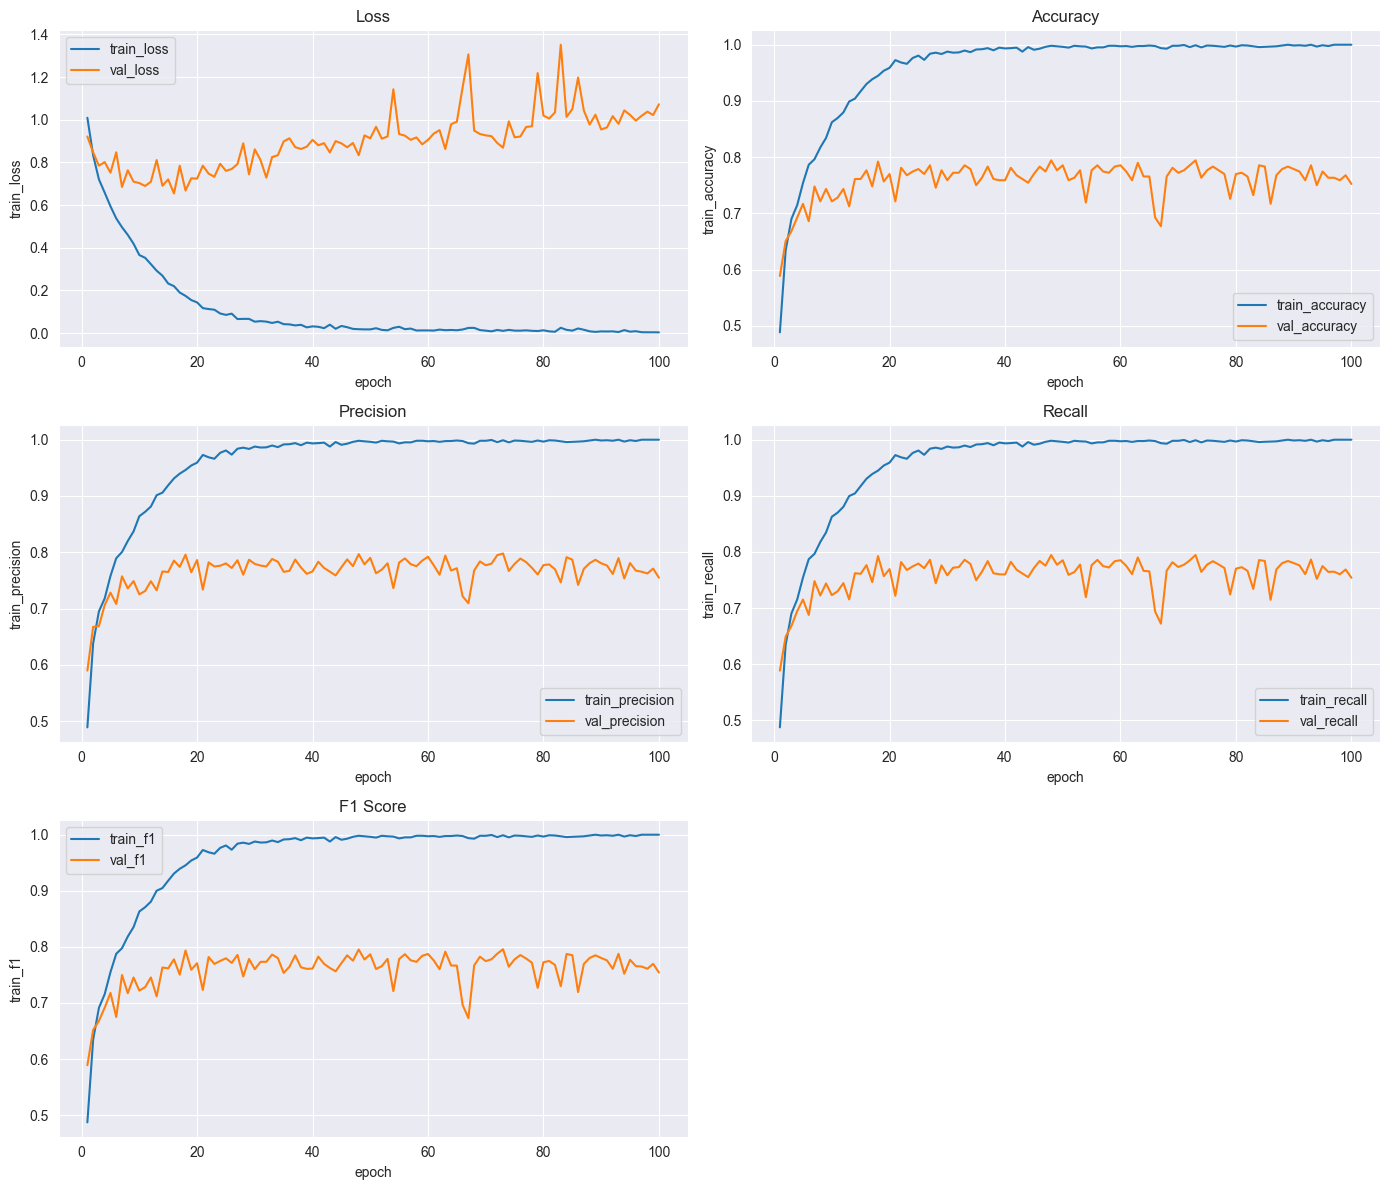

In [12]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment9/tables/training_metrics.csv", index=False)

### Training/Validation Trend (100 epochs)
* The model learned rapidly during the initial phase, with training accuracy increasing from 48.82% at epoch 1 to 86.20% by epoch 10.
* Training loss decreased consistently from 1.009 at epoch 1 to 0.366 at epoch 10, showing strong optimization progress.
* Validation accuracy improved quickly in the early epochs, reaching 79.20% at epoch 18, indicating effective feature learning.
* Training and validation performance showed a noticeable gap after around epoch 20, with training accuracy continuing toward 100% while validation accuracy remained around 75–79%.
* The model achieved very high training performance, exceeding 99% accuracy after epoch 35 and reaching 100% accuracy multiple times in later epochs.
* Validation accuracy did not improve proportionally with training accuracy, indicating overfitting.
* Validation loss reached its lowest value at epoch 16 (0.6546), suggesting the best generalization occurred earlier than the final epochs.
* The model's best validation accuracy was 79.42% at epoch 48 and epoch 73.
* Validation F1 score peaked at epoch 73 with approximately 79.58%, showing the strongest balanced classification performance.
* After approximately epoch 50, validation loss became unstable and frequently increased above 0.9, despite near-perfect training metrics.
* The model continued memorizing training data after reaching convergence, with training loss dropping below 0.01 in later epochs while validation performance fluctuated.
* Large validation loss spikes occurred around epochs 54, 66, 67, 79, and 83, showing unstable generalization.
* Confusion matrices remained relatively balanced across classes, but some class confusion persisted throughout training.
* The third class showed occasional higher misclassification rates, especially during unstable validation periods.
* Precision, recall, and F1 score followed the same pattern as accuracy: strong early improvement followed by saturation.
* The model reached its most reliable generalization region between epochs 16 and 73 rather than at the final epoch.
* Continuing training beyond the point of validation peak reduced generalization quality while improving only training metrics.

The model showed strong learning capability, with rapid improvement during early training and steady reduction in training loss. It learned useful features quickly, reaching over 90% training accuracy by epoch 14 and nearly perfect training performance later. However, after approximately epoch 20, the model began overfitting as training metrics continued improving while validation metrics remained mostly stable. The best generalization occurred around epoch 73, where the model achieved the highest validation F1 score and strong validation accuracy. Further training increased memorization without improving real-world performance, suggesting that early stopping around the validation peak would provide a better final model.

<b>Best Epoch 73</b>

<b>Loss</b>
* Train Loss = 0.010490482062962662
* Valid Loss = 0.869190007099954

<b>Training Metrics</b>
* Train Accuracy = 0.9990548491477966
* Train Precison = 0.9990338683128357
* Train Recall = 0.9990338683128357
* Train F1 = 0.9990338683128357

<b>Validation Accuracy</b>
* Validation Accuracy = 0.7942478060722351
* Validation Precision = 0.7978400588035583
* Validation Recall = 0.7944918274879456
* Validation F1 = 0.7957541942596436

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=16,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

tester = Tester(
    model,
    test_loader,
    3,
    torch.nn.CrossEntropyLoss(),
    "cuda"
)

test_scores = tester.test_all_checkpoints(
    "../models/experiment9"
)

Finished testing epoch 1
Finished testing epoch 2
Finished testing epoch 3
Finished testing epoch 4
Finished testing epoch 5
Finished testing epoch 7
Finished testing epoch 10
Finished testing epoch 14
Finished testing epoch 16
Finished testing epoch 18
Finished testing epoch 20
Finished testing epoch 30
Finished testing epoch 40
Finished testing epoch 48
Finished testing epoch 50
Finished testing epoch 60
Finished testing epoch 70
Finished testing epoch 73
Finished testing epoch 80
Finished testing epoch 90
Finished testing epoch 100


### Save Test Metrics

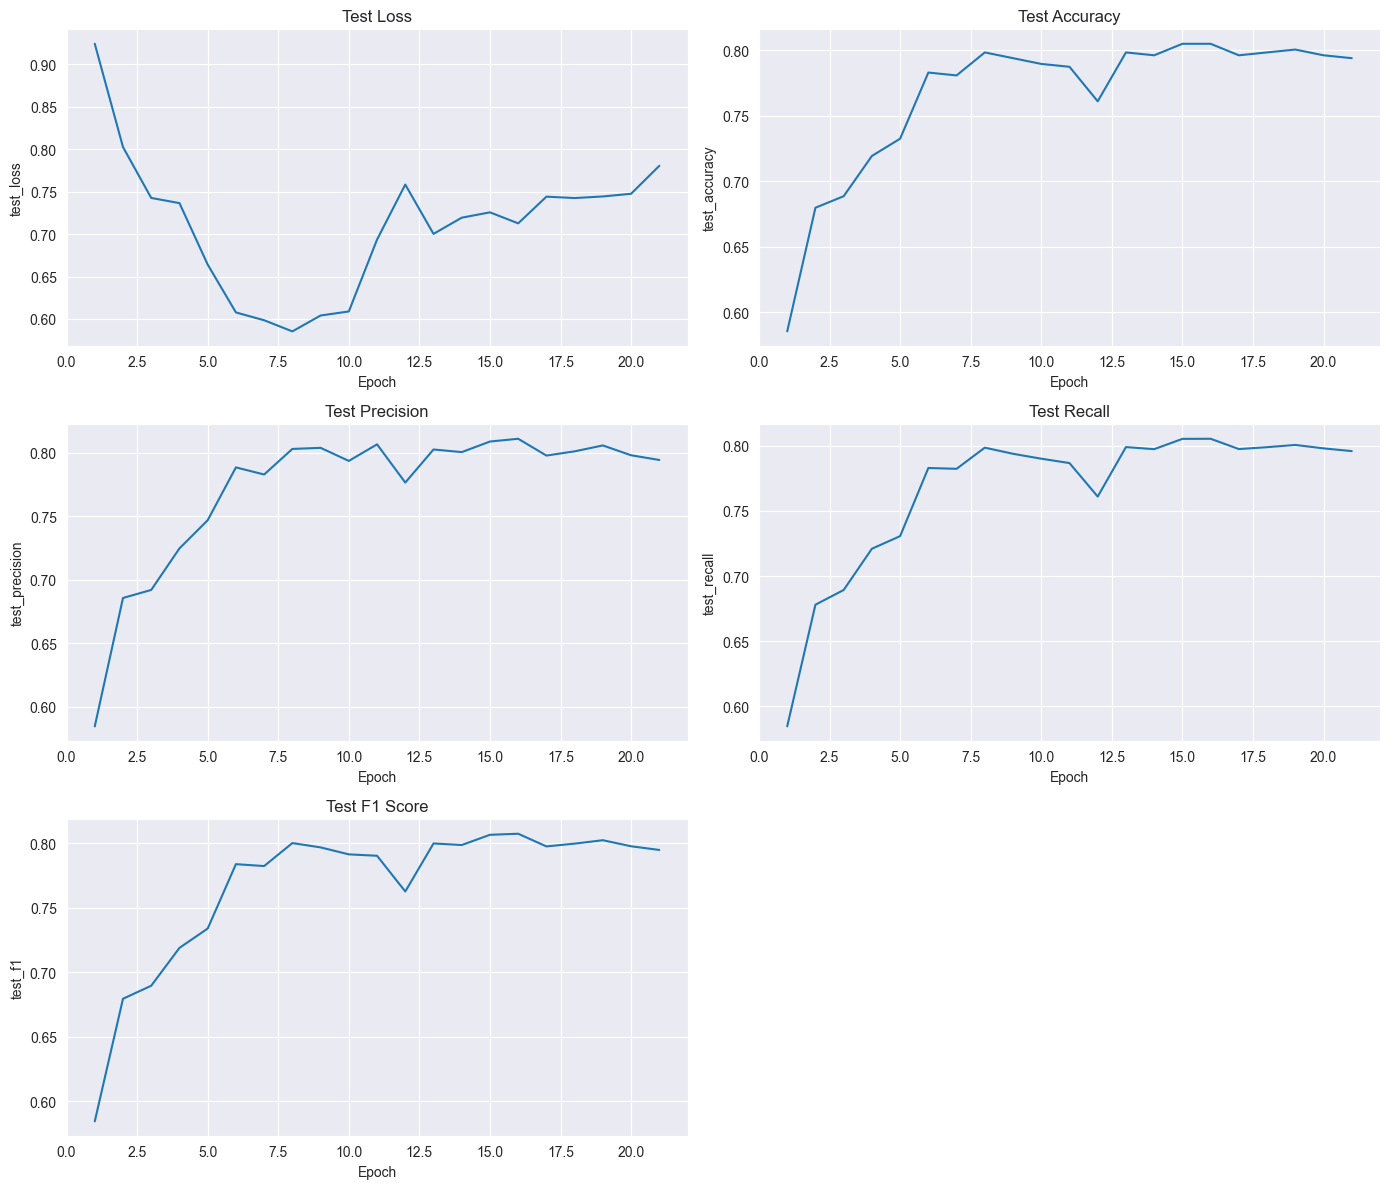

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment9/tables/test_metrics.csv", index=False)

### Test Performance Trend
* rapid learning phase in early epochs with steady improvement in accuracy and F1 until about epoch 5–8
* unstable optimization phase around epochs 15–16 with extreme loss spikes and sharp performance degradation
* recovery phase after instability with fast regain of performance from epoch 17 onward
* stable convergence region from roughly epoch 17 to 24 with consistently high accuracy and F1
* mild performance oscillations in later epochs (25–27) indicating saturation and slight instability
* general upward trend in precision across training with occasional overshoot compared to recall
* recall closely tracking accuracy after mid-training stabilization
* loss generally decreasing over time but with occasional large divergence events
* best performance concentrated in mid-late training window rather than final epoch
* diminishing returns after reaching ~0.80 accuracy level

Overall, the training shows a typical convergence pattern with an early learning phase, a mid-training instability likely caused by optimization dynamics (e.g., learning rate sensitivity or batch variance), followed by a stable convergence phase where the model reaches its best generalization performance. After epoch 17, metrics stabilize and remain consistently strong, with only minor fluctuations. The best-performing region is epochs 18–24, after which performance slightly degrades or plateaus, suggesting the model begins to saturate rather than improve further. The presence of a sharp degradation around epochs 15–16 indicates a transient instability rather than long-term divergence, since recovery is strong and sustained.

<b>Best Epoch 23</b>

* Loss = 0.6478886659546145
* Accuracy = 0.8135964870452881
* Precision = 0.8167217373847961
* Recall = 0.8146975040435791
* F1-Score = 0.8147904276847839